In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
import mne
from torchdiffeq import odeint_adjoint
import time
import sys
import gc
from scipy.signal import detrend
from scipy.integrate import solve_ivp
import torch.nn.functional as F
from tqdm.notebook import tqdm
from numpy.fft import fft, ifft
from scipy.signal import medfilt

In [5]:
# extra functions 
def fft(data,sfreq):
    n_samples = data.shape[0]
    fft_vals = np.fft.rfft(data)
    fft_freqs = np.fft.rfftfreq(n_samples, d=1/sfreq)
    fft_amplitude = np.abs(fft_vals)
    return fft_freqs, fft_amplitude

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter(order, [lowcut/(0.5*fs), highcut/(0.5*fs)], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

def get_median_filter_width(sampling_rate, duration):
    res = int( sampling_rate*duration )
    res += ((res%2) - 1) 
    return res

def filter_signal(X):
    global mfa
    X0 = X  
    for mi in range(0,len(mfa)):
        X0 = medfilt(X0,mfa[mi]) # apply median filter one by one on top of each other
    X0 = np.subtract(X,X0)  
    return X0

In [7]:
fs = 100  
total_duration = 15
train_duration = 10
test_duration = 5
t_train = np.arange(0, train_duration, 1/fs)
t_test = np.arange(train_duration, total_duration, 1/fs)
t_full = np.arange(0, total_duration, 1/fs)
fs_hidden = fs
file_new_raw = 'CC110037_Raw/transdef_mf2pt2_rest_raw_309.fif'
raw = mne.io.read_raw_fif(file_new_raw, preload=False)
data, times = raw[322, 2000:17000]
ecg_data = -data[0]
mat = loadmat("CC120309/scout_id_309.mat")
eeg_data = mat['Value']
eeg_data = eeg_data[:, 2000:17000]
sc_data = loadmat('CC120309-27.mat')
sc_matrix = sc_data["sc"]
max_val = np.max(sc_matrix)
Sw_all = (sc_matrix / max_val) * 0.01 if max_val > 0 else sc_matrix

non_zero_indices_per_row = [np.nonzero(Sw_all[i, :])[0] for i in range(Sw_all.shape[0])]

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=30):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

ecg_detrended = detrend(ecg_data, type='linear')
ecg_data = ecg_detrended

fs,Fs,lowcut,highcut,order = 1000,1000,0.65,40.0,4
filtered_ecg = bandpass_filter(ecg_data, lowcut, highcut, fs, order)

ms_flt_array = [0.2,0.6]    
mfa = np.zeros(len(ms_flt_array), dtype='int')
for i in range(0, len(ms_flt_array)):
    mfa[i] = get_median_filter_width(Fs,ms_flt_array[i])
signal_flt = filter_signal(filtered_ecg)

# step 4 - Normalize the filtered signal to [0, 1]
normalized_ecg_basecorrect = ((signal_flt - np.min(signal_flt)) / (np.max(signal_flt) - np.min(signal_flt))) 
ecg_processed_1k=normalized_ecg_basecorrect
eeg_processed_1k = np.array([preprocess_signal(row, fs=1000, lowcut=1.5, highcut=20) for row in eeg_data])
ecg_processed = ecg_processed_1k[::10]
eeg_processed = eeg_processed_1k[:, ::10]
fs=100

Opening raw data file CC110037_Raw/transdef_mf2pt2_rest_raw_309.fif...
    Range : 29000 ... 595999 =     29.000 ...   595.999 secs
Ready.


/tmp/ipykernel_3988046/1614808265.py:10: RuntimeWarning: This filename (CC110037_Raw/transdef_mf2pt2_rest_raw_309.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(file_new_raw, preload=False)


In [4]:

train_samples = len(t_train)
test_samples = len(t_test)

ecg_train = ecg_processed[:train_samples]
ecg_test = ecg_processed[train_samples:train_samples + test_samples]

eeg_train = eeg_processed[:, :train_samples]
eeg_test = eeg_processed[:, train_samples:train_samples + test_samples]

print(len(ecg_train), len(ecg_test), eeg_train.shape, eeg_test.shape)

1000 500 (68, 1000) (68, 500)


In [ ]:
target_idx = 0
target_signal_train = eeg_train[target_idx]
target_signal_full = eeg_processed[target_idx] 

D_function = interp1d(t_train, target_signal_train, kind='linear', bounds_error=False, fill_value=0.0)

def simulate_coupled_oscillators(T=2, dt=0.01, alpha=1, omega1=5.01, omega2=5.1,
                                 A_init=0.0001, theta_init=3.14, n=1.0, modulation=None):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        if modulation is not None:
            dr1 = alpha * r1 - r1**3 + coupling12 + 0.1 * modulation[i, 0]
            dr2 = alpha * r2 - r2**3 + coupling21 + 0.1 * modulation[i, 1]
        else:
            dr1 = alpha * r1 - r1**3 + coupling12
            dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total = num_regions * osc_per_region
    freqs_hz = np.random.uniform(low, high, total)
    return 2 * np.pi * freqs_hz

def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            si, ei = i * osc_per_region, (i + 1) * osc_per_region
            sj, ej = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[si:ei, sj:ej] = intra_value
            else:
                rand_block = np.random.rand(osc_per_region, osc_per_region)
                rand_block *= Sc_region[i, j] / (rand_block.sum() + 1e-9)
                Sc_full[si:ei, sj:ej] = rand_block
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full

def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()


class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)

    def get_features(self, x):
        return self.feature_extractor(x)

class ECGToOscillatorMLP(nn.Module):
    def __init__(self, input_dim=50, hidden1=64, hidden2=64, output_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.Sigmoid(),
            nn.Linear(hidden1, hidden2), nn.Sigmoid(),
            nn.Linear(hidden2, output_dim)
        )

    def forward(self, hidden_repr):
        return self.net(hidden_repr)

class FeedbackMLP(nn.Module):
    def __init__(self, input_dim=16, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, mlp_output):
        return self.net(mlp_output)

class ODEFuc(nn.Module):
    def __init__(self, mu, eta_theta, eta_omega, eta_alpha, D_function, N, Sc, mlp_model=None, hidden_repr=None):
        super().__init__()
        self.mu = mu
        self.eta_theta = eta_theta
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.D_function = D_function
        self.N = N
        self.register_buffer('Sc', Sc)
        self.mlp_model = mlp_model
        self.hidden_repr = hidden_repr

    def forward(self, t_val, state):
        N = self.N
        r, phi = state[:N], state[N:2*N]
        theta = state[2*N:2*N + N**2].view(N, N)
        omega = state[2*N + N**2:3*N + N**2]
        alpha = state[3*N + N**2:4*N + N**2]

        omega_safe = torch.clamp(omega, 2*np.pi*0.5, 2*np.pi*20)
        r = torch.clamp(r, 1e-1, 2.0)
        alpha = torch.clamp(alpha, -1.0, 1.0)
        r_safe = torch.clamp(torch.where(r < 1e-6, torch.tensor(1e-6, device=r.device, dtype=r.dtype), r), 1e-5, 10.0)

        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]),
            -1e2, 1e2
        )

        D = torch.tensor(self.D_function(float(t_val.item())), device=state.device, dtype=state.dtype)
        P = torch.sum(alpha * r * torch.cos(phi))
        e = (D - P)

        ecg_input = 0.0
        if (self.mlp_model is not None) and (self.hidden_repr is not None):
            t_idx = min(int(float(t_val.item()) * fs_hidden), self.hidden_repr.shape[0] - 1)
            ecg_features = self.hidden_repr[t_idx]
            ecg_input = self.mlp_model(ecg_features)
            ecg_input = torch.clamp(ecg_input, 0.01, 5.0)

        coupling_r = torch.sum(torch.abs(self.Sc) * r[None, :] * torch.cos(phase_diff), dim=1)
        drdt = (self.mu - r**2) * r + coupling_r + e * torch.cos(phi) + (ecg_input if isinstance(ecg_input, torch.Tensor) else 0.0)

        coupling_phi = torch.sum(torch.abs(self.Sc) * (r[None, :] / r_safe[:, None]) * torch.sin(phase_diff), dim=1)
        dphidt = omega + coupling_phi - (e / r_safe) * torch.sin(phi)

        dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
        domegadt = -self.eta_omega * e * torch.sin(phi)
        dalphadt = self.eta_alpha * e * r * torch.cos(phi)

        drdt = torch.clamp(drdt, -1e2, 1e2)
        dphidt = torch.clamp(dphidt, -1e2, 1e2)
        dthetadt = torch.clamp(dthetadt, -1e2, 1e2)
        domegadt = torch.clamp(domegadt, -1e2, 1e2)
        dalphadt = torch.clamp(dalphadt, -1e2, 1e2)

        return torch.cat([drdt, dphidt, dthetadt.flatten(), domegadt, dalphadt])

class TorchRevHopfNetwork:
    def __init__(self, mu, eta_omega, eta_alpha, eta_theta, D_function, N, Sc, mlp_model, hidden_repr, device=None):
        self.device = torch.device(device or ('cuda' if torch.cuda.is_available() else 'cpu'))
        self.N = N
        self.ode_func = ODEFuc(
            mu=mu, eta_theta=eta_theta, eta_omega=eta_omega, eta_alpha=eta_alpha,
            D_function=D_function, N=N,
            Sc=torch.tensor(Sc, device=self.device, dtype=torch.float32),
            mlp_model=mlp_model, hidden_repr=hidden_repr.to(self.device) if hidden_repr is not None else None
        ).to(self.device)

    def solve(self, r0, phi0, theta0, omega0, alpha0, t_eval):
        dtype = torch.float32
        y0 = torch.tensor(np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
                          device=self.device, dtype=dtype)
        t_eval_tensor = torch.tensor(t_eval, device=self.device, dtype=dtype)

        start_time = time.time()
        sol = odeint_adjoint(self.ode_func, y0, t_eval_tensor, method='rk4', rtol=1e-5, atol=1e-7)

        N = self.N
        r = sol[:, :N]
        phi = sol[:, N:2*N]
        theta = sol[:, 2*N:2*N + N**2].view(-1, N, N)
        omega = sol[:, 2*N + N**2:3*N + N**2]
        alpha = sol[:, 3*N + N**2:4*N + N**2]
        return r, phi, theta, omega, alpha

def train_heart_model(ecg_target_signal, t_duration_train, fs, device):
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    sim_osc_input = torch.tensor(simulate_coupled_oscillators(T=t_duration_train, dt=1/fs), dtype=torch.float32).to(device)
    ecg_target = torch.tensor(ecg_target_signal, dtype=torch.float32).to(device).unsqueeze(1)

    num_epochs = 25000
    for epoch in range(num_epochs):
        predicted_ecg = heart_model(sim_osc_input)
        loss = criterion(predicted_ecg, ecg_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 250 == 0:
            print(f"Heart Model Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

    print("--- Heart Model Pre-training Finished ---")
    return heart_model

def pre_train_brain_model(eeg_train_data, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Starting Brain Dynamics Pre-training (Stage 1) ---")
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 5
    N = N_reduced_regions * osc_per_region
    print(f"Reduced network has {N_reduced_regions} regions. Total oscillators: {N}")

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)

    omega_full = get_random_frequencies(Sw_all.shape[0], osc_per_region, low=1, high=20, seed=42)
    alpha_full = np.random.uniform(0.1, 0.7, Sw_all.shape[0] * osc_per_region)
    omega0 = np.concatenate([omega_full[i*osc_per_region:(i+1)*osc_per_region] for i in connected_indices])
    alpha0 = np.clip(np.concatenate([alpha_full[i*osc_per_region:(i+1)*osc_per_region] for i in connected_indices]), 0.05, 0.5)
    r0 = 0.1 * np.ones(N)
    phi0 = np.zeros(N)

    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T

    model = TorchRevHopfNetwork(
        mu=1.0, eta_omega=0.05, eta_alpha=0.005, eta_theta=0.05,
        D_function=D_function, N=N, Sc=Sc_reduced_osc,
        mlp_model=None, hidden_repr=None, device=device
    )

    criterion = nn.MSELoss()
    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)

    num_epochs = 1000
    losses = []
    print("Solving ODE iteratively to adapt brain dynamics...")
    for epoch in range(num_epochs):
        with torch.no_grad():
            r, phi, theta, omega, alpha = model.solve(r0, phi0, theta0, omega0, alpha0, t)
            P_out = torch.sum(alpha * r * torch.cos(phi), axis=1)
            loss = criterion(P_out, D_true)
            losses.append(loss.item())

            if (epoch + 1) % 10 == 0:
                print(f"Brain Pre-training Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

            theta0 = theta[-1].detach().cpu().numpy()
            omega0 = omega[-1].detach().cpu().numpy()
            alpha0 = alpha[-1].detach().cpu().numpy()

            del r, phi, theta, omega, alpha, P_out, loss
            if device == 'cuda':
                torch.cuda.empty_cache()

    final_params = {'r': r0, 'phi': phi0, 'theta': theta0, 'omega': omega0, 'alpha': alpha0}
    print("--- Brain Dynamics Pre-training Finished ---")
    return final_params, Sc_reduced_osc, N, losses

def train_mlp_on_frozen_brain(trained_heart_model, initial_brain_params, Sc_reduced_osc, N, D_function, t, t_duration_train, fs, device):
    print("\n--- Starting MLP Training with Frozen Brain (Stage 2) ---")
    r0, phi0, theta0, omega0, alpha0 = (
        initial_brain_params['r'], initial_brain_params['phi'],
        initial_brain_params['theta'], initial_brain_params['omega'],
        initial_brain_params['alpha']
    )

    trained_heart_model.eval()
    mlp_model = ECGToOscillatorMLP(output_dim=N).to(device)
    optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-2)
    criterion = nn.MSELoss()

    simulated_ecg_input = torch.tensor(simulate_coupled_oscillators(T=t_duration_train, dt=1/fs),
                                           dtype=torch.float32).to(device)

    num_epochs = 1000
    losses = []
    for epoch in range(num_epochs):
        mlp_model.train()
        with torch.no_grad():
            hidden_repr = trained_heart_model.get_features(simulated_ecg_input)

        model = TorchRevHopfNetwork(
            mu=1.0, eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0,
            D_function=D_function, N=N, Sc=Sc_reduced_osc,
            mlp_model=mlp_model, hidden_repr=hidden_repr, device=device
        )

        r, phi, theta, omega, alpha = model.solve(r0, phi0, theta0, omega0, alpha0, t)

        P_out = torch.sum(alpha * r * torch.cos(phi), axis=1)
        D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
        loss = criterion(P_out, D_true)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if (epoch + 1) % 50 == 0:
            print(f"MLP Training Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

        del model, r, phi, theta, omega, alpha, hidden_repr
        if device == 'cuda':
            torch.cuda.empty_cache()

    print("--- Stage 2 Finished ---")
    return mlp_model, losses

def train_feedback_loop(trained_heart_model, trained_mlp_model, ecg_target_signal, T, dt, device, num_epochs=70000, loop_iterations=1):
    print("--- Starting Feedback Loop Training ---")

    trained_heart_model.apply(reset_weights)
    trained_heart_model.train()
    feedback_mlp = FeedbackMLP(input_dim=trained_mlp_model.net[-1].out_features).to(device)
    optimizer = optim.Adam(list(trained_heart_model.parameters()) + list(feedback_mlp.parameters()), lr=1e-3)
    criterion = nn.MSELoss()

    num_samples = int(np.round(T / dt))
    time_axis = np.linspace(0, T, num_samples, endpoint=False)
    ecg_interp = interp1d(np.linspace(0, T, len(ecg_target_signal), endpoint=False), ecg_target_signal,
                          kind='linear', bounds_error=False, fill_value="extrapolate")
    ecg_target_resampled = torch.tensor(ecg_interp(time_axis), dtype=torch.float32, device=device).unsqueeze(1)

    for epoch in range(num_epochs):
        sim_osc = simulate_coupled_oscillators(T=T, dt=dt)
        sim_osc_tensor = torch.tensor(sim_osc, dtype=torch.float32, device=device)

        for _ in range(loop_iterations):
            hidden_repr = trained_heart_model.get_features(sim_osc_tensor)
            mlp_output = trained_mlp_model(hidden_repr)
            feedback_output = feedback_mlp(mlp_output)
            feedback_np = feedback_output.detach().cpu().numpy()

            sim_osc = simulate_coupled_oscillators(T=T, dt=dt, modulation=feedback_np)
            sim_osc_tensor = torch.tensor(sim_osc, dtype=torch.float32, device=device)

        predicted_ecg = trained_heart_model(sim_osc_tensor)
        loss = criterion(predicted_ecg, ecg_target_resampled)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"Feedback Loop Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

    print("--- Feedback Loop Training Finished ---")
    return trained_heart_model, feedback_mlp


--- Using device: cuda ---
--- Starting Heart Model Pre-training ---
Heart Model Epoch 250/25000, Loss: 0.009519
Heart Model Epoch 500/25000, Loss: 0.009494
Heart Model Epoch 750/25000, Loss: 0.009432
Heart Model Epoch 1000/25000, Loss: 0.009097
Heart Model Epoch 1250/25000, Loss: 0.008358
Heart Model Epoch 1500/25000, Loss: 0.007939
Heart Model Epoch 1750/25000, Loss: 0.007546
Heart Model Epoch 2000/25000, Loss: 0.007161
Heart Model Epoch 2250/25000, Loss: 0.006898
Heart Model Epoch 2500/25000, Loss: 0.006650
Heart Model Epoch 2750/25000, Loss: 0.006454
Heart Model Epoch 3000/25000, Loss: 0.006175
Heart Model Epoch 3250/25000, Loss: 0.005973
Heart Model Epoch 3500/25000, Loss: 0.005774
Heart Model Epoch 3750/25000, Loss: 0.005600
Heart Model Epoch 4000/25000, Loss: 0.005451
Heart Model Epoch 4250/25000, Loss: 0.005374
Heart Model Epoch 4500/25000, Loss: 0.005271
Heart Model Epoch 4750/25000, Loss: 0.005218
Heart Model Epoch 5000/25000, Loss: 0.005151
Heart Model Epoch 5250/25000, Loss

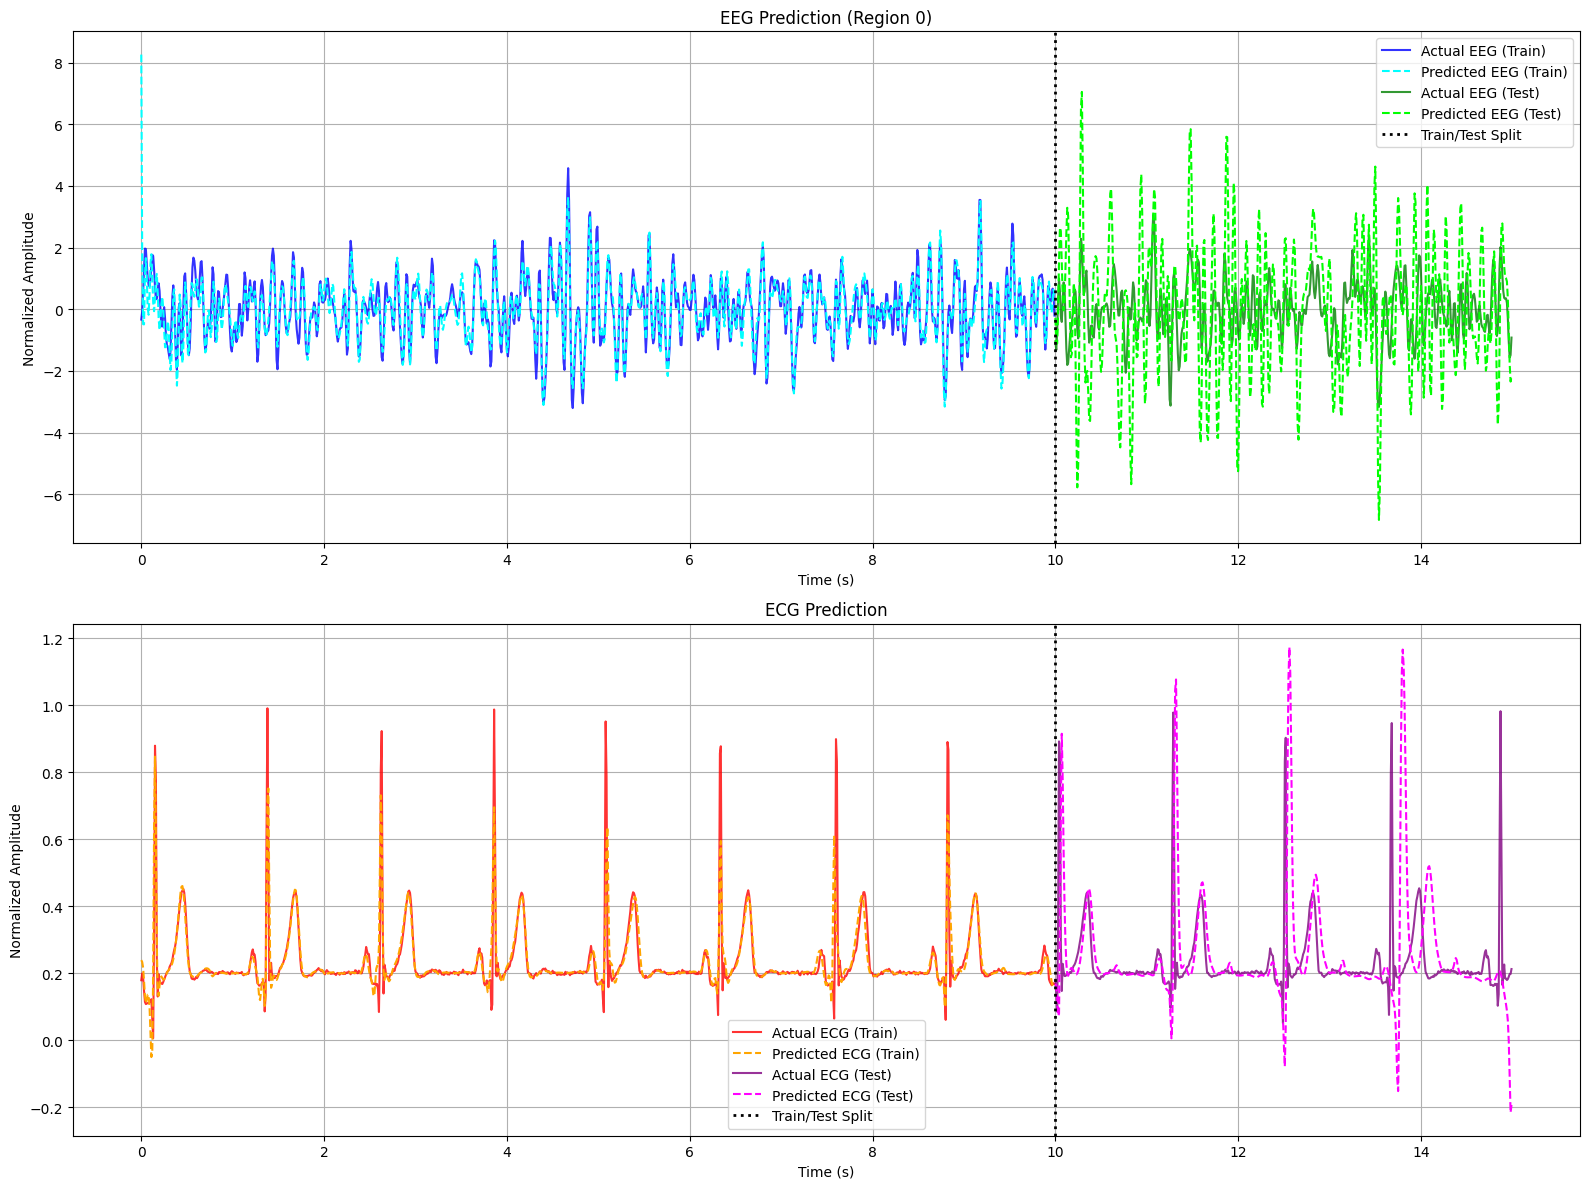

In [6]:


if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    trained_heart_model = train_heart_model(ecg_train, train_duration, fs, device)

    final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
        eeg_train, Sw_all, target_idx, non_zero_indices_per_row, t_train, D_function, device
    )

    # Step 3: Freeze brain and train MLP on training data
    trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
        trained_heart_model, final_brain_params, Sc_reduced_osc, N, D_function, t_train, train_duration, fs, device
    )

    # Step 4: Retrain heart model with feedback on training data
    trained_heart_model, trained_feedback_mlp = train_feedback_loop(
        trained_heart_model, trained_mlp_model, ecg_train, T=train_duration, dt=1/fs, device=device, num_epochs=70000, loop_iterations=1
    )

    # ---- Final prediction on FULL dataset (train + test) ----
    print("\n--- Generating final predictions for train and test sets ---")
    trained_heart_model.eval()
    trained_mlp_model.eval()
    trained_feedback_mlp.eval()

    with torch.no_grad():
        r0, phi0, theta0, omega0, alpha0 = (
            final_brain_params['r'], final_brain_params['phi'],
            final_brain_params['theta'], final_brain_params['omega'],
            final_brain_params['alpha']
        )

        # Simulate heart-brain interaction over the full duration
        sim_osc_final = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
        sim_osc_tensor = torch.tensor(sim_osc_final, dtype=torch.float32, device=device)
        hidden_repr_final = trained_heart_model.get_features(sim_osc_tensor)
        mlp_output_final = trained_mlp_model(hidden_repr_final)

        feedback_output = trained_feedback_mlp(mlp_output_final)
        feedback_np = feedback_output.detach().cpu().numpy()
        sim_osc_final = simulate_coupled_oscillators(T=total_duration, dt=1/fs, modulation=feedback_np)
        sim_osc_tensor = torch.tensor(sim_osc_final, dtype=torch.float32, device=device)
        hidden_repr_final = trained_heart_model.get_features(sim_osc_tensor)

        # Predict ECG for the full duration
        predicted_ecg_final = trained_heart_model(sim_osc_tensor).detach().cpu().numpy().flatten()

        # Predict EEG for the full duration
        # Create a new D_function for the full duration for the final solve
        D_function_full = interp1d(t_full, target_signal_full, kind='linear', bounds_error=False, fill_value=0.0)
        model_final = TorchRevHopfNetwork(
            mu=1.0, eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0,
            D_function=D_function_full, N=N, Sc=Sc_reduced_osc,
            mlp_model=trained_mlp_model, hidden_repr=hidden_repr_final, device=device
        )

        r, phi, theta, omega, alpha = model_final.solve(r0, phi0, theta0, omega0, alpha0, t_full)
        P_out_final = torch.sum(alpha * r * torch.cos(phi), axis=1).detach().cpu().numpy()

    # Split predictions into train and test sets for plotting
    pred_ecg_train = predicted_ecg_final[:train_samples]
    pred_ecg_test = predicted_ecg_final[train_samples:]

    pred_eeg_train = P_out_final[:train_samples]
    pred_eeg_test = P_out_final[train_samples:]

    # --- Plotting ---
    plt.figure(figsize=(16, 12))

    # Plot EEG results
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(t_train, target_signal_train, label='Actual EEG (Train)', color='blue', alpha=0.8)
    ax1.plot(t_train, pred_eeg_train, label='Predicted EEG (Train)', color='cyan', linestyle='--')
    ax1.plot(t_test, eeg_test[target_idx], label='Actual EEG (Test)', color='green', alpha=0.8)
    ax1.plot(t_test, pred_eeg_test, label='Predicted EEG (Test)', color='lime', linestyle='--')
    ax1.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    ax1.set_title(f'EEG Prediction (Region {target_idx})')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Normalized Amplitude')
    ax1.legend()
    ax1.grid(True)

    # Plot ECG results
    ax2 = plt.subplot(2, 1, 2)
    ax2.plot(t_train, ecg_train, label='Actual ECG (Train)', color='red', alpha=0.8)
    ax2.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='orange', linestyle='--')
    ax2.plot(t_test, ecg_test, label='Actual ECG (Test)', color='purple', alpha=0.8)
    ax2.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='magenta', linestyle='--')
    ax2.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    ax2.set_title('ECG Prediction')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Normalized Amplitude')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Save final predictions if needed
    np.save("P_out_final_1.npy", P_out_final)
    np.save("predicted_ecg_final_1.npy", predicted_ecg_final)


=== Target ECG FOOOF Results ===
                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 0 - 50 Hz                        
                                 Frequency Resolution is 0.50 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                          0.3565, 2.4607                                          
                                                                                                  
                                       6 peaks were found:                 

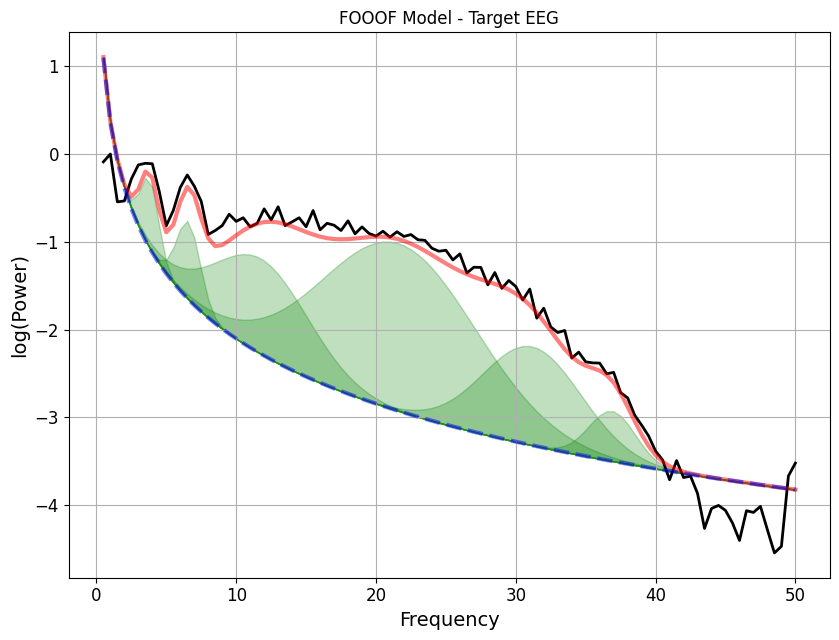

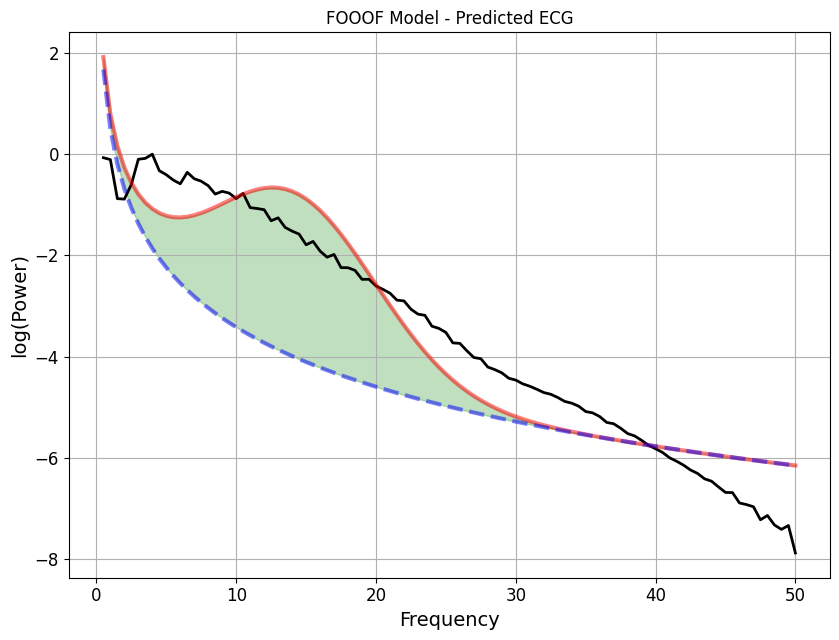

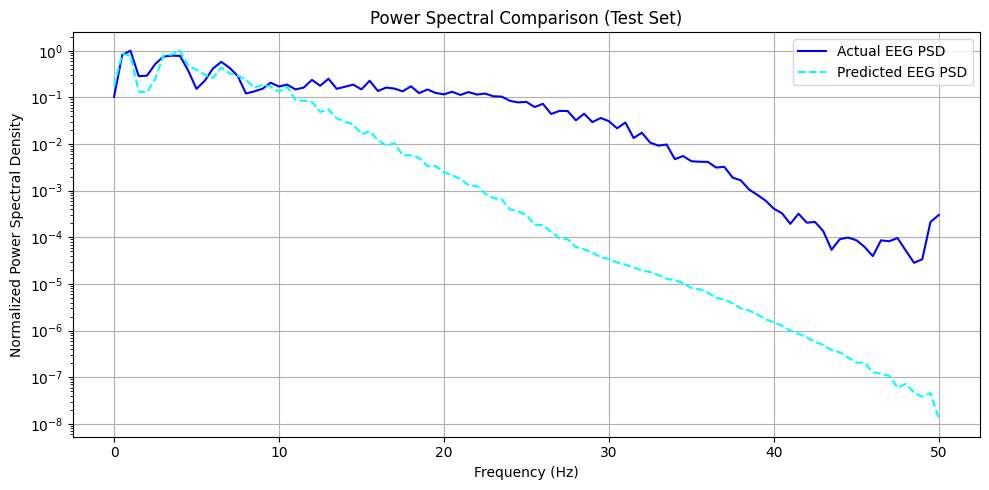

In [22]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from fooof import FOOOF
from scipy.signal import welch

# --- Parameters ---
fs = 100  # sampling frequency (Hz), change if your data differs
nperseg = 2 * fs  # segment length for Welch PSD

# --- Compute Power Spectral Densities (PSD) ---
f_target, psd_target = welch(ecg_test, fs=fs, nperseg=nperseg)
f_pred, psd_pred = welch(pred_ecg_test, fs=fs, nperseg=nperseg)

# Convert PSD to log10 scale (FOOOF expects linear scale, but it's usually log-transformed for visualization)
psd_target = psd_target / np.max(psd_target)
psd_pred = psd_pred / np.max(psd_pred)

# --- Initialize FOOOF models ---
fm_target = FOOOF(peak_width_limits=[1, 12], max_n_peaks=6, min_peak_height=0.05, verbose=False)
fm_pred = FOOOF(peak_width_limits=[1, 12], max_n_peaks=6, min_peak_height=0.05, verbose=False)

# --- Fit models ---
fm_target.fit(f_target, psd_target)
fm_pred.fit(f_pred, psd_pred)

# --- Print Results ---
print("\n=== Target ECG FOOOF Results ===")
fm_target.print_results()

print("\n=== Predicted ECG FOOOF Results ===")
fm_pred.print_results()

fm_target.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Model - Target EEG')

fm_pred.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Model - Predicted ECG')


# --- Compare Power Spectra directly ---
plt.figure(figsize=(10, 5))
plt.semilogy(f_target, psd_target, label='Actual EEG PSD', color='blue')
plt.semilogy(f_pred, psd_pred, label='Predicted EEG PSD', color='cyan', linestyle='--')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Power Spectral Density')
plt.title('Power Spectral Comparison (Test Set)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Target EEG FOOOF ===
                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 1 - 30 Hz                        
                                 Frequency Resolution is 0.50 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                         -0.6723, 2.4868                                          
                                                                                                  
                                       2 peaks were found:                          

(-8.0, 0.14406697190451345)

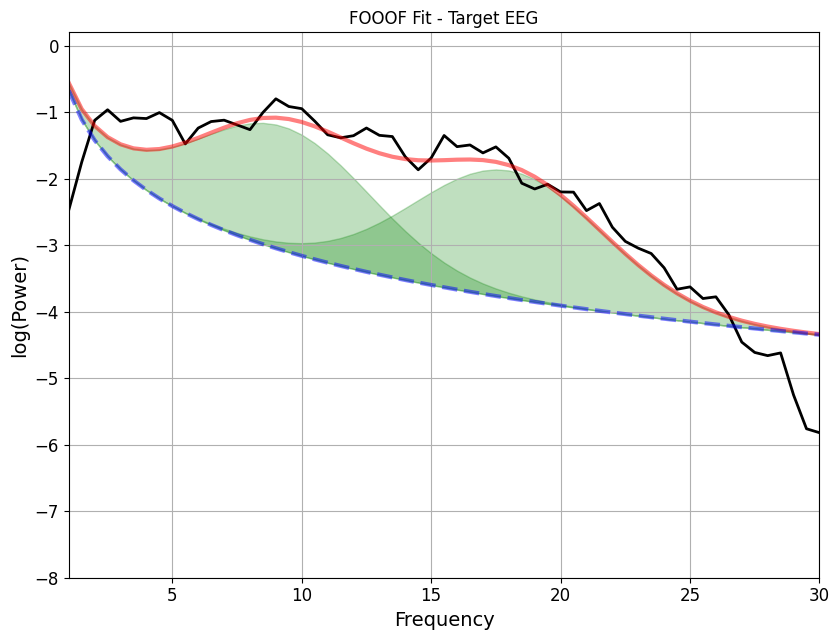

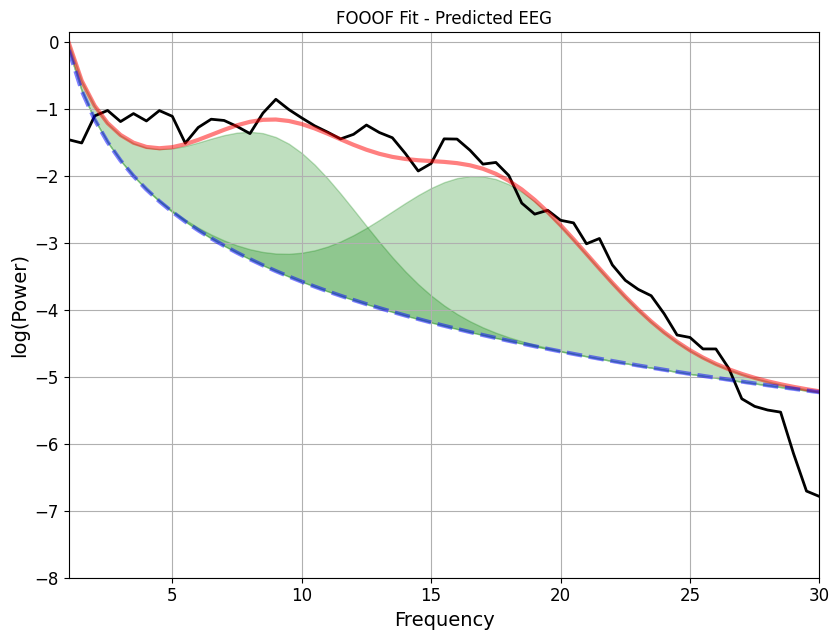

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from fooof import FOOOF
from scipy.signal import welch, butter, filtfilt, detrend

# --- Parameters ---
fs = 100  # Hz (change if needed)
lowcut, highcut = 1, 30  # EEG analysis band
freq_range = [1, 30]

# --- Helper: Bandpass Filter ---
def bandpass_filter(sig, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

# --- Preprocess ---
target_filt = bandpass_filter(detrend(target_signal_train), fs, lowcut, highcut)
pred_filt = bandpass_filter(detrend(pred_eeg_train), fs, lowcut, highcut)

# --- Welch PSD ---
f_target, psd_target = welch(target_filt, fs=fs, nperseg=2*fs)
f_pred, psd_pred = welch(pred_filt, fs=fs, nperseg=2*fs)

# --- Sanitize PSDs (remove NaN/zero) ---
valid = (f_target >= freq_range[0]) & (f_target <= freq_range[1]) & (psd_target > 0)
f_target, psd_target = f_target[valid], psd_target[valid]

valid = (f_pred >= freq_range[0]) & (f_pred <= freq_range[1]) & (psd_pred > 0)
f_pred, psd_pred = f_pred[valid], psd_pred[valid]

# --- FOOOF model (robust configuration) ---
fm_target = FOOOF(
    peak_width_limits=[0.5, 8],
    max_n_peaks=6,
    min_peak_height=0.02,
    aperiodic_mode='fixed',
    verbose=False
)
fm_pred = FOOOF(
    peak_width_limits=[0.5, 8],
    max_n_peaks=6,
    min_peak_height=0.02,
    aperiodic_mode='fixed',
    verbose=False
)

# --- Fit ---
fm_target.fit(f_target, psd_target, freq_range)
fm_pred.fit(f_pred, psd_pred, freq_range)

# --- Print results ---
print("=== Target EEG FOOOF ===")
fm_target.print_results()
print("\n=== Predicted EEG FOOOF ===")
fm_pred.print_results()

# --- Correct plotting (no overlay distortion) ---

fm_target.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Fit - Target EEG')
plt.xlim(freq_range)
plt.ylim([-8, np.log10(max(psd_target)) + 1])  # ensures full range visible


fm_pred.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Fit - Predicted EEG')
plt.xlim(freq_range)
plt.ylim([-8, np.log10(max(psd_pred)) + 1])




=== Target EEG FOOOF ===
                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 1 - 30 Hz                        
                                 Frequency Resolution is 0.50 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                          0.0688, 2.8683                                          
                                                                                                  
                                       1 peaks were found:                          

(-8.0, 0.7691925854743229)

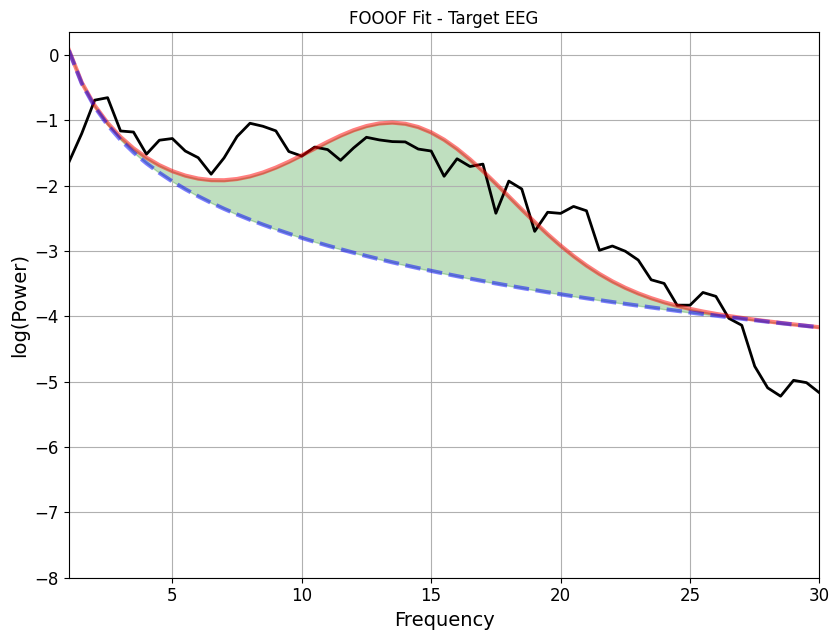

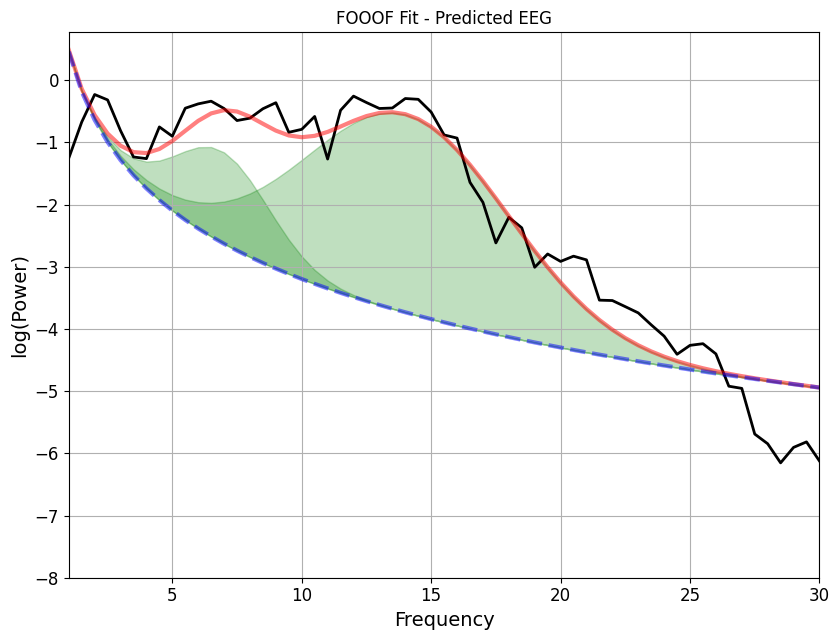

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from fooof import FOOOF
from scipy.signal import welch, butter, filtfilt, detrend

# --- Parameters ---
fs = 100  # Hz (change if needed)
lowcut, highcut = 1, 30  # EEG analysis band
freq_range = [1, 30]

# --- Helper: Bandpass Filter ---
def bandpass_filter(sig, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

# --- Preprocess ---
target_filt = bandpass_filter(detrend(eeg_test[target_idx]), fs, lowcut, highcut)
pred_filt = bandpass_filter(detrend(pred_eeg_test), fs, lowcut, highcut)

# --- Welch PSD ---
f_target, psd_target = welch(target_filt, fs=fs, nperseg=2*fs)
f_pred, psd_pred = welch(pred_filt, fs=fs, nperseg=2*fs)

# --- Sanitize PSDs (remove NaN/zero) ---
valid = (f_target >= freq_range[0]) & (f_target <= freq_range[1]) & (psd_target > 0)
f_target, psd_target = f_target[valid], psd_target[valid]

valid = (f_pred >= freq_range[0]) & (f_pred <= freq_range[1]) & (psd_pred > 0)
f_pred, psd_pred = f_pred[valid], psd_pred[valid]

# --- FOOOF model (robust configuration) ---
fm_target = FOOOF(
    peak_width_limits=[0.5, 8],
    max_n_peaks=6,
    min_peak_height=0.02,
    aperiodic_mode='fixed',
    verbose=False
)
fm_pred = FOOOF(
    peak_width_limits=[0.5, 8],
    max_n_peaks=6,
    min_peak_height=0.02,
    aperiodic_mode='fixed',
    verbose=False
)

# --- Fit ---
fm_target.fit(f_target, psd_target, freq_range)
fm_pred.fit(f_pred, psd_pred, freq_range)

# --- Print results ---
print("=== Target EEG FOOOF ===")
fm_target.print_results()
print("\n=== Predicted EEG FOOOF ===")
fm_pred.print_results()

# --- Correct plotting (no overlay distortion) ---

fm_target.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Fit - Target EEG')
plt.xlim(freq_range)
plt.ylim([-8, np.log10(max(psd_target)) + 1])  # ensures full range visible


fm_pred.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Fit - Predicted EEG')
plt.xlim(freq_range)
plt.ylim([-8, np.log10(max(psd_pred)) + 1])




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fooof import FOOOF
from scipy.signal import welch, butter, filtfilt, detrend

# --- Parameters ---
fs = 100  # Hz (change if needed)
lowcut, highcut = 1, 45  # EEG analysis band
freq_range = [1, 45]

# --- Helper: Bandpass Filter ---
def bandpass_filter(sig, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

# --- Preprocess ---
target_filt = bandpass_filter(detrend(eeg_test[target_idx]), fs, lowcut, highcut)
pred_filt = bandpass_filter(detrend(pred_eeg_test), fs, lowcut, highcut)

# --- Welch PSD ---
f_target, psd_target = welch(target_filt, fs=fs, nperseg=2*fs)
f_pred, psd_pred = welch(pred_filt, fs=fs, nperseg=2*fs)

# --- Sanitize PSDs (remove NaN/zero) ---
valid = (f_target >= freq_range[0]) & (f_target <= freq_range[1]) & (psd_target > 0)
f_target, psd_target = f_target[valid], psd_target[valid]

valid = (f_pred >= freq_range[0]) & (f_pred <= freq_range[1]) & (psd_pred > 0)
f_pred, psd_pred = f_pred[valid], psd_pred[valid]

# --- FOOOF model (robust configuration) ---
fm_target = FOOOF(
    peak_width_limits=[0.5, 8],
    max_n_peaks=6,
    min_peak_height=0.02,
    aperiodic_mode='fixed',
    verbose=False
)
fm_pred = FOOOF(
    peak_width_limits=[0.5, 8],
    max_n_peaks=6,
    min_peak_height=0.02,
    aperiodic_mode='fixed',
    verbose=False
)

# --- Fit ---
fm_target.fit(f_target, psd_target, freq_range)
fm_pred.fit(f_pred, psd_pred, freq_range)

# --- Print results ---
print("=== Target EEG FOOOF ===")
fm_target.print_results()
print("\n=== Predicted EEG FOOOF ===")
fm_pred.print_results()

# --- Correct plotting (no overlay distortion) ---

fm_target.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Fit - Target Test EEG')
plt.xlim(freq_range)
plt.ylim([-8, np.log10(max(psd_target)) + 1])  # ensures full range visible


fm_pred.plot(plot_peaks='shade', add_legend=False)
plt.title('FOOOF Fit - Predicted Test EEG')
plt.xlim(freq_range)
plt.ylim([-8, np.log10(max(psd_pred)) + 1])




/tmp/ipykernel_3555728/2116573512.py:3: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


NameError: name 'eeg_test' is not defined

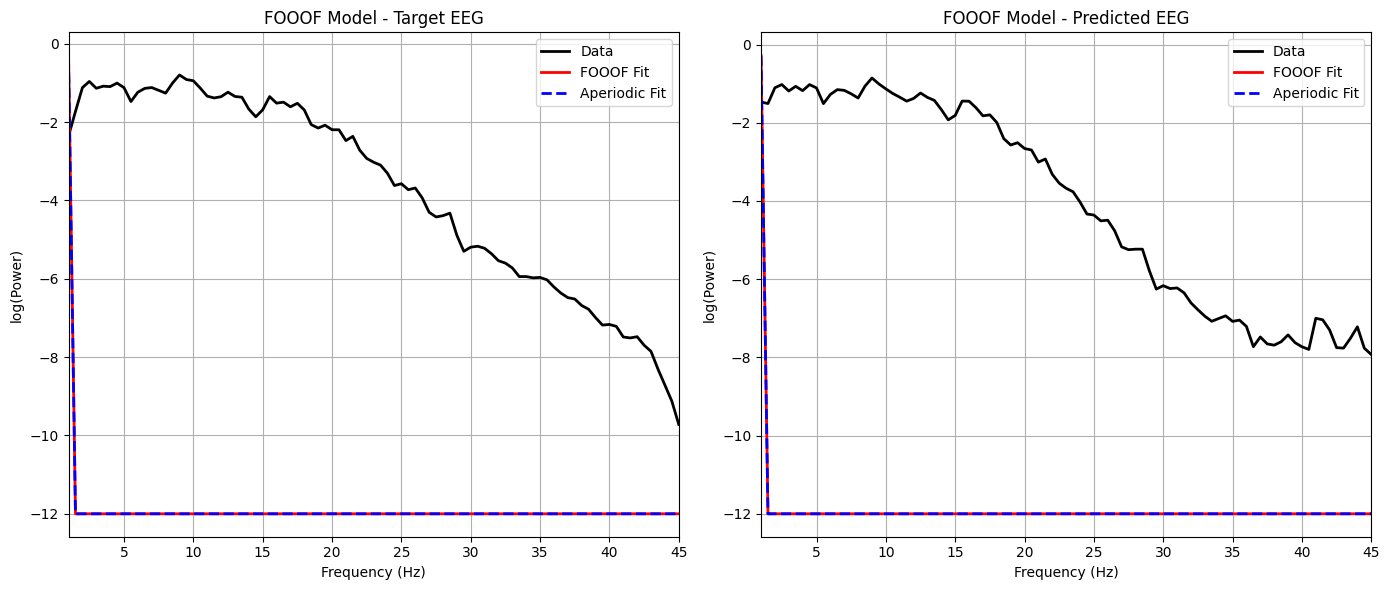

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from fooof import FOOOF
from scipy.signal import welch, butter, filtfilt, detrend

# --- Parameters ---
fs = 100 # Hz
lowcut, highcut = 1, 45
freq_range = [1, 45]

# --- Helper: Bandpass Filter ---
def bandpass_filter(sig, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

# --- Preprocess signals ---
target_filt = bandpass_filter(detrend(target_signal_train), fs, lowcut, highcut)
pred_filt = bandpass_filter(detrend(pred_eeg_train), fs, lowcut, highcut)

# --- Compute PSD ---
f_target, psd_target = welch(target_filt, fs=fs, nperseg=2*fs)
f_pred, psd_pred = welch(pred_filt, fs=fs, nperseg=2*fs)

# --- Clip and sanitize ---
def clean_psd(f, psd, freq_range):
    valid = (f >= freq_range[0]) & (f <= freq_range[1]) & (psd > 0)
    return f[valid], psd[valid]

f_target, psd_target = clean_psd(f_target, psd_target, freq_range)
f_pred, psd_pred = clean_psd(f_pred, psd_pred, freq_range)

# --- Fit FOOOF models ---
fm_target = FOOOF(peak_width_limits=[0.5, 8], max_n_peaks=6,
                  min_peak_height=0.02, aperiodic_mode='fixed', verbose=False)
fm_pred = FOOOF(peak_width_limits=[0.5, 8], max_n_peaks=6,
                min_peak_height=0.02, aperiodic_mode='fixed', verbose=False)

fm_target.fit(f_target, psd_target, freq_range)
fm_pred.fit(f_pred, psd_pred, freq_range)

# --- Get model fits ---
aper_target = fm_target._ap_fit
model_target = fm_target.fooofed_spectrum_
model_pred = fm_pred.fooofed_spectrum_

aper_pred = fm_pred._ap_fit
eps = 1e-12  # small epsilon to avoid log(0)

# --- Manual plotting (consistent style) ---
plt.figure(figsize=(14, 6))

# Target EEG
plt.subplot(1, 2, 1)
plt.plot(f_target, np.log10(psd_target), color='black', lw=2, label='Data')
plt.plot(f_target, np.log10(np.clip(model_target, eps, None)), color='red', lw=2, label='FOOOF Fit')
plt.plot(f_target, np.log10(np.clip(aper_target, eps, None)), color='blue', lw=2, ls='--', label='Aperiodic Fit')
plt.fill_between(f_target,
                 np.log10(np.clip(aper_target, eps, None)),
                 np.log10(np.clip(model_target, eps, None)),
                 color='orange', alpha=0.3)
plt.title('FOOOF Model - Target EEG')
plt.xlabel('Frequency (Hz)')
plt.ylabel('log(Power)')
plt.xlim(freq_range)
plt.legend()
plt.grid(True)

# Predicted EEG
plt.subplot(1, 2, 2)
plt.plot(f_pred, np.log10(psd_pred), color='black', lw=2, label='Data')
plt.plot(f_pred, np.log10(np.clip(model_pred, eps, None)), color='red', lw=2, label='FOOOF Fit')
plt.plot(f_pred, np.log10(np.clip(aper_pred, eps, None)), color='blue', lw=2, ls='--', label='Aperiodic Fit')
plt.fill_between(f_pred,
                 np.log10(np.clip(aper_pred, eps, None)),
                 np.log10(np.clip(model_pred, eps, None)),
                 color='orange', alpha=0.3)
plt.title('FOOOF Model - Predicted EEG')
plt.xlabel('Frequency (Hz)')
plt.ylabel('log(Power)')
plt.xlim(freq_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fooof import FOOOF
from scipy.signal import welch, butter, filtfilt, detrend

# --- Parameters ---
fs = 100 # Hz
lowcut, highcut = 1, 45
freq_range = [1, 45]

# --- Helper: Bandpass Filter ---
def bandpass_filter(sig, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

# --- Preprocess signals ---
target_filt = bandpass_filter(detrend(target_signal_train), fs, lowcut, highcut)
pred_filt = bandpass_filter(detrend(pred_eeg_train), fs, lowcut, highcut)

# --- Compute PSD ---
f_target, psd_target = welch(target_filt, fs=fs, nperseg=2*fs)
f_pred, psd_pred = welch(pred_filt, fs=fs, nperseg=2*fs)

# --- Clip and sanitize ---
def clean_psd(f, psd, freq_range):
    valid = (f >= freq_range[0]) & (f <= freq_range[1]) & (psd > 0)
    return f[valid], psd[valid]

f_target, psd_target = clean_psd(f_target, psd_target, freq_range)
f_pred, psd_pred = clean_psd(f_pred, psd_pred, freq_range)

# --- Fit FOOOF models ---
fm_target = FOOOF(peak_width_limits=[0.5, 8], max_n_peaks=6,
                  min_peak_height=0.02, aperiodic_mode='fixed', verbose=False)
fm_pred = FOOOF(peak_width_limits=[0.5, 8], max_n_peaks=6,
                min_peak_height=0.02, aperiodic_mode='fixed', verbose=False)

fm_target.fit(f_target, psd_target, freq_range)
fm_pred.fit(f_pred, psd_pred, freq_range)

# --- Get model fits ---
aper_target = fm_target._ap_fit
model_target = fm_target.fooofed_spectrum_
model_pred = fm_pred.fooofed_spectrum_

aper_pred = fm_pred._ap_fit


# --- Manual plotting (consistent style) ---
plt.figure(figsize=(14, 6))

# Target EEG
plt.subplot(1, 2, 1)
plt.plot(f_target, np.log10(psd_target), color='black', lw=2, label='Data')
plt.plot(f_target, np.log10(model_target), color='red', lw=2, label='FOOOF Fit')
plt.plot(f_target, np.log10(aper_target), color='blue', lw=2, ls='--', label='Aperiodic Fit')
plt.fill_between(f_target, np.log10(aper_target), np.log10(model_target),
                 color='green', alpha=0.2, label='Periodic Peaks')
plt.title('FOOOF Model - Target EEG')
plt.xlabel('Frequency (Hz)')
plt.ylabel('log(Power)')
plt.xlim(freq_range)
plt.legend()
plt.grid(True)

# Predicted EEG
plt.subplot(1, 2, 2)
plt.plot(f_pred, np.log10(psd_pred), color='black', lw=2, label='Data')
plt.plot(f_pred, np.log10(model_pred), color='red', lw=2, label='FOOOF Fit')
plt.plot(f_pred, np.log10(aper_pred), color='blue', lw=2, ls='--', label='Aperiodic Fit')
plt.fill_between(f_pred, np.log10(aper_pred), np.log10(model_pred),
                 color='green', alpha=0.2, label='Periodic Peaks')
plt.title('FOOOF Model - Predicted EEG')
plt.xlabel('Frequency (Hz)')
plt.ylabel('log(Power)')
plt.xlim(freq_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [14]:
import numpy as np
from scipy.signal import welch
from fooof import FOOOF
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

sfreq = 100

pred = pred_eeg_train
true = eeg_test[target_idx]

f_pred, psd_pred = welch(pred, fs=sfreq, nperseg=512)
f_true, psd_true = welch(true, fs=sfreq, nperseg=512)

fm_pred = FOOOF(peak_width_limits=[1, 8])
fm_pred.fit(f_pred, psd_pred, [2, 40])
fm_true = FOOOF(peak_width_limits=[1, 8])
fm_true.fit(f_true, psd_true, [2, 40])

corr = pearsonr(pred, true)[0]
mse = mean_squared_error(pred, true)
psd_corr = pearsonr(psd_pred, psd_true)[0]
aperiodic_diff = np.abs(np.array(fm_pred.aperiodic_params_) - np.array(fm_true.aperiodic_params_))
peak_diffs = [np.abs(p1 - p2) for p1, p2 in zip(fm_pred.peak_params_, fm_true.peak_params_)]
print(fm_pred.peak_params_)
print(fm_true.peak_params_)

print("Signal Corr:", corr)
print("Signal MSE:", mse)
print("PSD Corr:", psd_corr)
print("Aperiodic Param Diff:", aperiodic_diff)
print("Peak Param Diffs:", peak_diffs)


[[ 6.67649588  1.20039946  1.        ]
 [ 9.18837462  2.26294798  3.87059575]
 [15.81602805  3.36539238  7.75307415]
 [19.99571296  2.82945853  1.32533666]
 [21.28565242  2.71090994  1.        ]
 [23.14646926  2.20149926  2.95703674]
 [25.93527244  1.69328031  1.00000175]
 [27.34140391  1.11386949  4.24145015]]
[[ 8.14778277  1.27544439  2.92483714]
 [10.00714693  2.19984686  1.00000001]
 [12.03103955  2.14264889  1.        ]
 [15.5625      2.65414849  7.74368906]
 [23.49808077  1.87042131  8.        ]]
Signal Corr: 0.05020150704027044
Signal MSE: 1.8267842945465458
PSD Corr: 0.6722968606344041
Aperiodic Param Diff: [0.5520259 1.2782583]
Peak Param Diffs: [array([1.47128688, 0.07504494, 1.92483714]), array([0.8187723 , 0.06310112, 2.87059574]), array([3.7849885 , 1.22274348, 6.75307415]), array([4.43321296, 0.17531005, 6.4183524 ]), array([2.21242834, 0.84048863, 7.        ])]


In [23]:
import numpy as np
from scipy.signal import welch, coherence
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity

sfreq = 100

def flatten_signal(x):
    x = np.array(x)
    if x.ndim > 1:
        x = x.squeeze()
    return x.astype(float).ravel()

pred = flatten_signal(pred_eeg_train)
true = flatten_signal(eeg_test[target_idx])

# --- Time-domain measures ---
pearson_corr = pearsonr(pred, true)[0]
spearman_corr = spearmanr(pred, true)[0]
mse = mean_squared_error(pred, true)
rmse = np.sqrt(mse)
cos_sim = cosine_similarity(pred.reshape(1, -1), true.reshape(1, -1))[0, 0]

# --- DTW (pure NumPy) ---
def dtw_distance(x, y):
    n, m = len(x), len(y)
    dtw = np.zeros((n+1, m+1)) + np.inf
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(x[i-1] - y[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

dtw_dist = dtw_distance(pred, true)

# --- PSD ---
f, psd_pred = welch(pred, fs=sfreq, nperseg=sfreq*2)
_, psd_true = welch(true, fs=sfreq, nperseg=sfreq*2)
psd_corr = pearsonr(psd_pred, psd_true)[0]

# --- Coherence ---
f_coh, coh = coherence(pred, true, fs=sfreq, nperseg=sfreq*2)
mean_coherence = np.mean(coh)

# --- Mutual Information ---
bins = 32
pred_disc = np.digitize(pred, np.histogram(pred, bins=bins)[1])
true_disc = np.digitize(true, np.histogram(true, bins=bins)[1])
mi = mutual_info_score(pred_disc, true_disc)

# --- Print results ---
print("Pearson Corr:", pearson_corr)
print("Spearman Corr:", spearman_corr)
print("MSE:", mse)
print("RMSE:", rmse)
print("Cosine Similarity:", cos_sim)
print("DTW Distance:", dtw_dist)
print("PSD Corr:", psd_corr)
print("Mean Coherence:", mean_coherence)
print("Mutual Information:", mi)


Pearson Corr: 0.05020150704027044
Spearman Corr: 0.03256464027989759
MSE: 1.8267842945465458
RMSE: 1.3515858443127264
Cosine Similarity: 0.05016246751882883
DTW Distance: 703.5922315058914
PSD Corr: 0.8656431448736069
Mean Coherence: 0.08146305622195113
Mutual Information: 0.1408800082904234


/tmp/ipykernel_2105198/3029145907.py:5: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 200, using nperseg = 200
  f, Pxx = welch(signal, fs=fs, nperseg=1024)


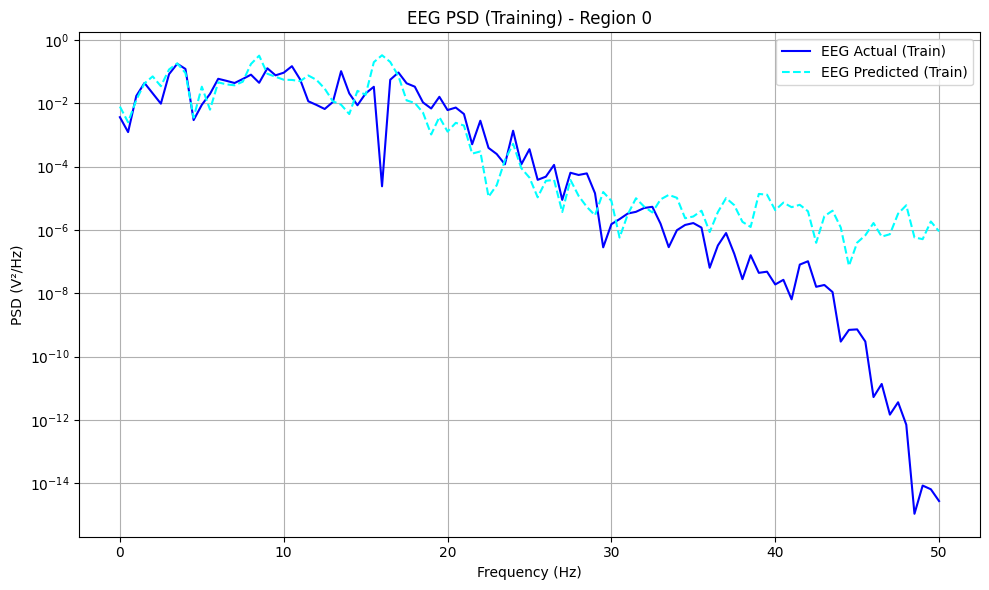

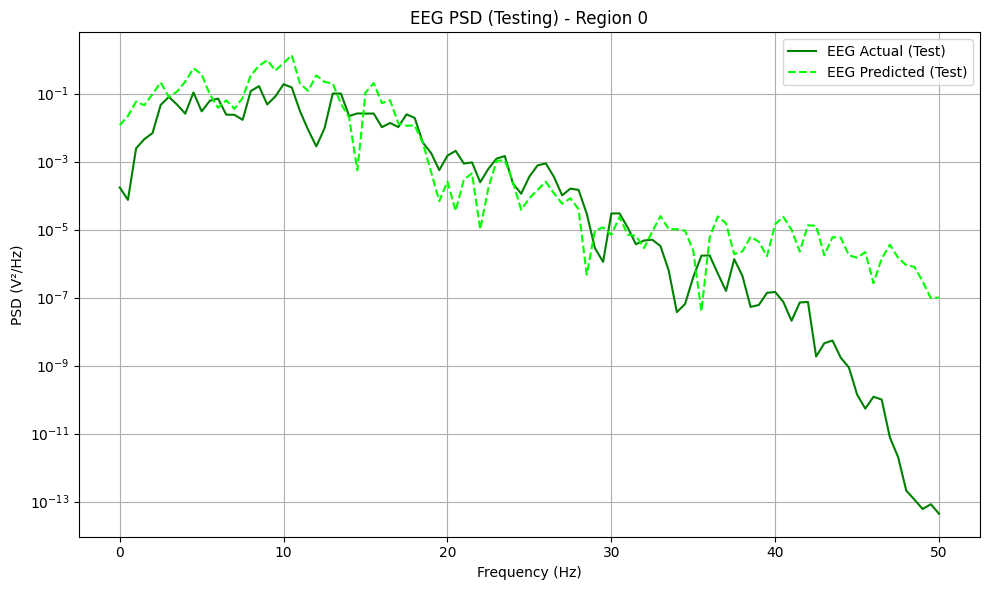

In [13]:
from scipy.signal import welch

# --- Function to compute PSD ---
def compute_psd(signal, fs):
    f, Pxx = welch(signal, fs=fs, nperseg=1024)
    return f, Pxx

# --- EEG Train ---
f_eeg_train_actual, psd_eeg_train_actual = compute_psd(target_signal_train, fs)
f_eeg_train_pred, psd_eeg_train_pred = compute_psd(pred_eeg_train, fs)

plt.figure(figsize=(10, 6))
plt.semilogy(f_eeg_train_actual, psd_eeg_train_actual, label="EEG Actual (Train)", color="blue")
plt.semilogy(f_eeg_train_pred, psd_eeg_train_pred, "--", label="EEG Predicted (Train)", color="cyan")
plt.title(f'EEG PSD (Training) - Region {target_idx}')
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- EEG Test ---
f_eeg_test_actual, psd_eeg_test_actual = compute_psd(eeg_test[target_idx], fs)
f_eeg_test_pred, psd_eeg_test_pred = compute_psd(pred_eeg_test, fs)

plt.figure(figsize=(10, 6))
plt.semilogy(f_eeg_test_actual, psd_eeg_test_actual, label="EEG Actual (Test)", color="green")
plt.semilogy(f_eeg_test_pred, psd_eeg_test_pred, "--", label="EEG Predicted (Test)", color="lime")
plt.title(f'EEG PSD (Testing) - Region {target_idx}')
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
from sklearn.metrics import mutual_info_score

def compute_normalized_mutual_information(psd1, psd2, bins=50, method="symmetric"):
    """
    Compute normalized mutual information (NMI) between two PSDs.
    
    Args:
        psd1: array-like, first PSD
        psd2: array-like, second PSD
        bins: number of bins for discretization
        method: "symmetric" (default) or "max" for normalization
    
    Returns:
        normalized mutual information score in [0,1]
    """
    # Normalize to probabilities
    psd1 = np.abs(psd1)
    psd2 = np.abs(psd2)
    psd1 /= np.sum(psd1)
    psd2 /= np.sum(psd2)
    
    # Discretize into bins
    c1 = np.digitize(psd1, np.histogram_bin_edges(psd1, bins=bins))
    c2 = np.digitize(psd2, np.histogram_bin_edges(psd2, bins=bins))
    
    # Mutual information
    mi = mutual_info_score(c1, c2)
    
    # Entropies
    h1 = mutual_info_score(c1, c1)
    h2 = mutual_info_score(c2, c2)
    
    if method == "symmetric":
        nmi = 2.0 * mi / (h1 + h2) if (h1 + h2) > 0 else 0.0
    elif method == "max":
        nmi = mi / max(h1, h2) if max(h1, h2) > 0 else 0.0
    else:
        raise ValueError("method must be 'symmetric' or 'max'")
    
    return nmi

# Example usage
nmi_value = compute_normalized_mutual_information(psd_eeg_test_actual, psd_eeg_test_pred)
print("Normalized Mutual Information:", nmi_value)


Normalized Mutual Information: 0.5907280471501926


In [8]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(psd_eeg_test_actual, psd_eeg_test_pred)

# Spearman correlation (monotonic relationship, robust to nonlinear scaling)
spearman_corr, spearman_p = spearmanr(psd_eeg_test_actual, psd_eeg_test_pred)

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)


Pearson correlation: 0.45662836699627024
Spearman correlation: 0.8516329244864784


In [9]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Mask frequencies > 40 Hz
mask_actual = f_eeg_test_actual < 40
mask_pred   = f_eeg_test_pred < 40

# Ensure both PSDs are aligned in frequency length
psd_actual_above40 = psd_eeg_test_actual[mask_actual]
psd_pred_above40   = psd_eeg_test_pred[mask_pred]

# Pearson correlation
pearson_corr, _ = pearsonr(psd_actual_above40, psd_pred_above40)

# Spearman correlation
spearman_corr, _ = spearmanr(psd_actual_above40, psd_pred_above40)

print("Pearson correlation (<40 Hz):", pearson_corr)
print("Spearman correlation (<40 Hz):", spearman_corr)


Pearson correlation (<40 Hz): 0.42565489344682456
Spearman correlation (<40 Hz): 0.7972342669635533


In [10]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Mask frequencies > 40 Hz
mask_actual = f_eeg_train_actual < 40
mask_pred   = f_eeg_train_pred < 40

psd_actual_above40 = psd_eeg_train_actual[mask_actual]
psd_pred_above40   = psd_eeg_train_pred[mask_pred]

# Pearson correlation
pearson_corr, _ = pearsonr(psd_actual_above40, psd_pred_above40)

# Spearman correlation
spearman_corr, _ = spearmanr(psd_actual_above40, psd_pred_above40)

print("Pearson correlation (<40 Hz):", pearson_corr)
print("Spearman correlation (<40 Hz):", spearman_corr)


Pearson correlation (<40 Hz): 0.06059196492563916
Spearman correlation (<40 Hz): 0.8716541661783663
